# Défi ÉquiAlgo - rapport d'audit

Audit d'équité du modèle d'octroi de bourses : **mesure du biais**, **métriques d'équité retenues et
justification**, **variables proxys**.

Carnets associés :
- `analyse_donnees.ipynb` : distributions et corrélations ;
- `model_corrige.ipynb` : cible contrefactuelle, front de Pareto et modèle corrigé.

Fonctions réutilisées : `analyse.py` (métriques, bootstrap, tranches) et `cible.py` (modèle de décision,
cible, modèle corrigé).

## 0. Résumé

| Constat | Valeur (IC 95 %) |
|---|---|
| Écart d'octroi du comité, Centre moins Éloignée | 21 points (19 à 23) |
| Part de cet écart justifiée par le mérite retenu | 0.8 point (-0.8 à 2.8) |
| Part due à la pénalité régionale directe, à profil égal | 18 points (15 à 21) |
| Écart d'égalité des chances du modèle de production, contre `decision_octroi` | 0.06 (0.01 à 0.11) |
| Le même écart, contre la référence de mérite (la nouvelle cible) | **0.32** (0.27 à 0.36) sur le test ; 0.30 sur les candidats, contre 0.270 annoncé par le scoreur |
| Après correction, contre les deux références indépendantes | -0.06 et -0.07, au lieu de 0.26 et 0.24 (négatif = en faveur des régions éloignées) |
| Exactitude contre l'étalon caché (HxBuddy) | comité sans correction 88.83 %, **cible retenue 94.58 %** |

1. Le comité pénalise les régions éloignées : sur les 21 points d'écart, le mérite retenu n'en justifie
   que 0.8. La pénalité régionale directe en explique 18, et le reste vient surtout de sa préférence pour
   les ménages aisés, que l'étalon caché ne partage pas.
2. Le modèle de production reproduit ces biais. L'audit de la baseline ne les voit pas, car il les
   mesure contre l'étiquette biaisée elle-même. La région est portée par des proxys (code postal,
   distance, heures, revenu) : la retirer ne suffit pas.
3. Le modèle corrigé, qui n'utilise ni la région, ni le code postal, ni la distance, ni le revenu, ramène
   l'écart à -0.06 et -0.07 contre les références indépendantes (légèrement en faveur des régions), à
   budget constant (40 %). Contre l'étalon, la cible retenue atteint 94.58 % d'exactitude, contre 88.83 %
   pour les décisions du comité sans correction.

Les chiffres sont recalculés par la dernière cellule du carnet (section 7). Les valeurs HxBuddy viennent
des sondes de `sondes_cible.ipynb`, et l'écart sur les candidats de `model_corrige.ipynb` §2.1.

## 1. Périmètre et méthode

**Ce qu'on audite.**
1. Le **comité** historique, `decision_octroi`, sur 10 000 dossiers.
2. Le **modèle de production** : la foret aleatoire de `baseline_model.ipynb`, entraînée sur toutes les
   colonnes, y compris la région.
3. Le **modèle corrigé** : la regression logistique entraînée sur la cible individuelle
   (`model_corrige.ipynb` §3), sans région, code postal, distance ni revenu.

**Groupes.** Centre (Montreal, Capitale-Nationale) et Eloignee (Bas-Saint-Laurent, Cote-Nord,
Gaspesie-Iles-de-la-Madeleine).

**Référence de mérite.** `decision_octroi` est biaisée et l'étalon du jury est caché. La référence
retenue est la décision du comité **sans sa pénalité régionale, et sans tenir compte du revenu ni de la
distance** (`cible.score_merite`). Elle a été calibrée contre l'étalon par des soumissions HxBuddy
(`sondes_cible.ipynb`, `model_corrige.ipynb` §1.5) : 94.58 % d'exactitude, contre 92.38 % pour la cible
initiale (pénalité régionale seule) et 88.83 % pour le comité. Deux références alternatives servent de
contrôle indépendant : le contrefactuel de région seule (cible initiale) et la cote R seule.

**Protocole.** Même découpage 70/30 que la baseline (stratifié, `random_state=42`). Les modèles sont
ajustés sur `train` et mesures sur `test`. Les intervalles de confiance à 95 % sont obtenus par
bootstrap, avec un rééchantillonnage stratifié par groupe.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

from analyse import (importance_permutation, intervalle_bootstrap, metriques_equite,
                     tableau_tranches, tracer_importances)
from cible import (VARIABLES_MODELE, ajouter_eloignee, ajuster_modele_decision, cible_individuelle,
                   coefficients, entrainer_modele_cible, octroi_par_tranche_r, octroi_top_k,
                   score_contrefactuel, score_merite)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

demandes = ajouter_eloignee(pd.read_csv('data/donnees_demandes.csv'))
candidats = ajouter_eloignee(pd.read_csv('data/candidats_evaluation.csv'))
groupe = np.where(demandes['eloignee'] == 1, 'Eloignee', 'Centre')
groupe_cand = np.where(candidats['eloignee'] == 1, 'Eloignee', 'Centre')

train, test = train_test_split(
    demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi']
)
groupe_tr, groupe_te = groupe[train.index], groupe[test.index]
y_comite = test['decision_octroi'].to_numpy()

# Palette de reference : Centre bleu, Eloignee orange ; textes en encre neutre.
COULEURS_GROUPE = {'Centre': '#2a78d6', 'Eloignee': '#eb6834'}
ENCRE, ENCRE_SECONDAIRE, GRILLE = '#0b0b0b', '#52514e', '#e4e3df'


def styliser(ax, titre=None):
    """Axes discrets : grille legere, sans cadre haut/droite."""
    if titre:
        ax.set_title(titre, color=ENCRE, fontsize=11, loc='left')
    ax.grid(color=GRILLE, lw=0.8)
    ax.set_axisbelow(True)
    for cote in ['top', 'right']:
        ax.spines[cote].set_visible(False)
    ax.tick_params(colors=ENCRE_SECONDAIRE)
    return ax

In [2]:
# Les trois modeles audites et les references de merite, sur le meme decoupage.
CATEGORIELLES_RF = ['programme_etudes', 'region_administrative', 'code_postal_3']


def encoder_rf(df_entrainement, df_cible, exclues=()):
    """Encodage de la baseline (one-hot, colonnes alignees), sans les colonnes `exclues`."""
    retirer = ['id_candidat', 'decision_octroi', 'eloignee', *exclues]
    categorielles = [c for c in CATEGORIELLES_RF if c not in exclues]
    X = pd.get_dummies(df_entrainement.drop(columns=retirer), columns=categorielles)
    Xc = pd.get_dummies(df_cible.drop(columns=retirer), columns=categorielles
                        ).reindex(columns=X.columns, fill_value=0)
    return X, Xc


def entrainer_rf(exclues=()):
    """RF de production ajuste sur train ; retourne (modele, X_test, decisions sur test)."""
    X_tr, X_te = encoder_rf(train, test, exclues)
    rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
    rf.fit(X_tr, train['decision_octroi'])
    return rf, X_te, rf.predict(X_te)


modele_valid = ajuster_modele_decision(train)
references = {
    'merite retenu': octroi_top_k(score_merite(modele_valid, test, reference=train)),
    'contrefactuel region seule': octroi_top_k(score_contrefactuel(modele_valid, test)),
    'cote R seule': octroi_top_k(test['cote_r_equivalent']),
}
y_ref = references['merite retenu']

rf, X_te_rf, decisions_rf = entrainer_rf()
modele_corrige = entrainer_modele_cible(train, cible_individuelle(modele_valid, train))
decisions_corrige = octroi_top_k(modele_corrige.predict_proba(test[VARIABLES_MODELE])[:, 1])

## 2. Mesure du biais

### 2.1 Le comité

**Décomposition de l'écart.** Le modèle de décision (regression logistique avec un indicateur
de région) reproduit le comité (AUC 0.954). On predit le taux d'octroi des candidats eloignes s'ils
avaient ete traites comme des candidats du Centre :
- la difference avec le taux du **Centre** est la part due au **profil** (cote R, revenu, heures...) ;
- la difference avec leur taux **observe** est la part **inexpliquée** par le profil, attribuable a
  la région.

Le modèle est reajuste a chaque tirage bootstrap (200 tirages).

In [3]:
def decomposer_ecart(indices):
    """Ecart d'octroi du comite, decompose selon le profil, la penalite regionale et le merite retenu."""
    s, g = demandes.iloc[indices], groupe[indices]
    modele = ajuster_modele_decision(s)
    centre = s.loc[g == 'Centre', 'decision_octroi'].mean()
    eloignee = s.loc[g == 'Eloignee', 'decision_octroi'].mean()
    eloignee_cf = score_contrefactuel(modele, s[g == 'Eloignee'], retrait=1).mean()
    merite = score_merite(modele, s)
    ecart_merite = merite[g == 'Centre'].mean() - merite[g == 'Eloignee'].mean()
    return {'ecart_total': centre - eloignee,
            'part_profil': centre - eloignee_cf,
            'part_inexpliquee': eloignee_cf - eloignee,
            'ecart_merite_retenu': ecart_merite,
            'part_non_justifiee': centre - eloignee - ecart_merite}


decomposition = intervalle_bootstrap(decomposer_ecart, np.arange(len(demandes)), strates=groupe, n=200)
print(decomposition.round(3))
print()
print('Taux d\'octroi par tranche de cote R (comite)')
print(octroi_par_tranche_r(demandes, demandes['decision_octroi']).round(3))

                     estimation    bas   haut
ecart_total               0.211  0.193  0.230
part_profil               0.030  0.004  0.061
part_inexpliquee          0.180  0.153  0.205
ecart_merite_retenu       0.008 -0.008  0.028
part_non_justifiee        0.203  0.187  0.217

Taux d'octroi par tranche de cote R (comite)
                   Centre  Eloignee
cote_r_equivalent                  
(0, 26]             0.020     0.005
(26, 27]            0.161     0.038
(27, 28]            0.316     0.100
(28, 29]            0.593     0.256
(29, 30]            0.849     0.568
(30, 32]            0.958     0.831
(32, 45]            0.998     0.986


**Lecture.**
- L'écart du comité est de **21 points** (IC 95 % : 19 à 23).
- À profil égal, tel que le comité le valorise (cote R, revenu, heures...), **18 points** (IC : 15 à 21)
  restent inexpliqués : c'est la pénalité régionale directe. Les 3 points restants (IC : 0.4 à 6)
  s'expliquent par le profil des candidats.
- Mais une partie de ces 3 points est elle-même un biais : le comité favorise les revenus élevés, plus
  rares en région. Avec le mérite retenu (sans revenu ni distance), l'écart de mérite entre les groupes
  n'est que de **0.8 point** (IC : -0.8 à 2.8, compatible avec zéro). Environ 20 points sur 21 ne sont
  donc pas justifiés par le mérite.
- À cote R égale, l'écart est massif : entre 28 et 29, le comité accorde à 59 % des candidats du Centre
  contre 26 % des candidats éloignés.
- L'écart est uniforme entre les trois régions éloignées et entre les programmes
  (`analyse_donnees.ipynb` §4) : c'est une pénalité constante liée à la région.

### 2.2 Le modèle de production

Le RF reproduit le comité. On le mesure contre `decision_octroi`.

TODO: clairifier la cellule ci-dessous. Un peu redondant et métriques peu significatif puisqu'on sait déjà qu'y_ref et y_comite sont alignés.

In [4]:
audit_rf = pd.concat({
    'contre decision_octroi': intervalle_bootstrap(metriques_equite, y_comite, decisions_rf, groupe_te,
                                                   strates=groupe_te),
    'contre la reference de merite': intervalle_bootstrap(metriques_equite, y_ref, decisions_rf, groupe_te,
                                                          strates=groupe_te),
}, axis=1)
print(audit_rf.round(3))

                        contre decision_octroi               contre la reference de merite              
                                    estimation    bas   haut                    estimation    bas   haut
taux_selection_Centre                    0.459  0.435  0.481                         0.459  0.435  0.481
taux_selection_Eloignee                  0.271  0.247  0.298                         0.271  0.247  0.298
ecart_parite                             0.188  0.155  0.221                         0.188  0.155  0.221
ecart_egalite_chances                    0.063  0.014  0.111                         0.315  0.273  0.357
ecart_fpr                                0.019 -0.006  0.046                         0.102  0.085  0.121
ecart_precision                          0.093  0.046  0.141                        -0.134 -0.157 -0.111
exactitude                               0.881  0.869  0.892                         0.909  0.900  0.919


**Lecture.**
- Contre `decision_octroi`, le RF paraît presque équitable : l'écart d'égalité des chances n'est que
  de 0.06. C'est la mesure de la baseline, et elle ne verifie que la **fidelite au comité**.
- Contre la référence de mérite, l'écart est de **0.32** (IC : 0.27 à 0.36). Parmi les candidats
  méritants, ceux des régions éloignées ont 32 points de moins de chances d'obtenir la bourse. Mesure
  sur les candidats avec la soumission gabarit, comme le fait le scoreur, il vaut 0.298, contre 0.270
  annonce (`model_corrige.ipynb` §2.1).
- L'écart de parité (0.19) est le meme quelle que soit l'étiquette, puisqu'il ne dépend que des
  decisions.

### 2.3 Analyse par tranches

Taux de sélection et TPR contre la référence, pour le RF et le modèle corrigé. La TPR d'une tranche
sans méritant est laissee vide. Les tranches de moins de 100 dossiers sont signalees par `*`.

In [5]:
def comparer_tranches(tranches):
    """Tableau par tranche du RF et du modele corrige, cote a cote."""
    tableau = pd.concat({
        'RF': tableau_tranches(y_ref, decisions_rf, tranches),
        'corrige': tableau_tranches(y_ref, decisions_corrige, tranches)[['taux_selection', 'tpr']],
    }, axis=1)
    tableau[('', 'faible effectif')] = np.where(tableau[('RF', 'effectif')] < 100, '*', '')
    return tableau


tranche_r = pd.cut(test['cote_r_equivalent'], [0, 26, 27, 28, 29, 30, 32, 45]).astype(str).rename('cote R')
g_te = pd.Series(groupe_te, index=test.index, name='groupe')

print(comparer_tranches(test['region_administrative'].rename('region')).round(3), end='\n\n')
print(comparer_tranches(pd.concat([test['programme_etudes'].rename('programme'), g_te], axis=1)).round(3), end='\n\n')
print(comparer_tranches(pd.concat([tranche_r, g_te], axis=1)).round(3), end='\n\n')
print(comparer_tranches(pd.concat([test['premiere_generation_universitaire'].rename('premiere generation'),
                                   g_te], axis=1)).round(3))

                                    RF                                        corrige                       
                              effectif meritants taux_selection    tpr taux_selection    tpr faible effectif
region                                                                                                      
Bas-Saint-Laurent                400.0     150.0          0.272  0.727          0.375  1.000                
Capitale-Nationale               611.0     242.0          0.458  0.983          0.398  1.000                
Cote-Nord                        364.0     147.0          0.261  0.646          0.401  0.993                
Gaspesie-Iles-de-la-Madeleine    461.0     193.0          0.278  0.663          0.419  1.000                
Montreal                        1164.0     468.0          0.459  0.998          0.402  1.000                

                                 RF                                        corrige                       
                     

TODO: pourquoi le graphique est bizarre?

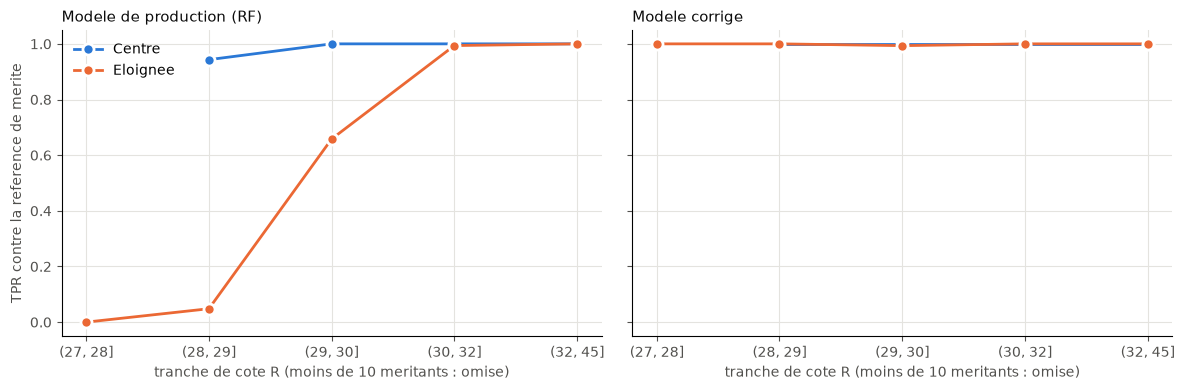

In [6]:
# TPR par tranche de cote R : RF contre modele corrige.
def tpr_par_tranche_r(decisions, min_meritants=10):
    """TPR par tranche de cote R et groupe ; tranches de moins de `min_meritants` meritants masquees."""
    tableau = tableau_tranches(y_ref, decisions, pd.concat([tranche_r, g_te], axis=1))
    return tableau['tpr'].where(tableau['meritants'] >= min_meritants).unstack()


tpr_r = {nom: tpr_par_tranche_r(d)
         for nom, d in [('Modele de production (RF)', decisions_rf), ('Modele corrige', decisions_corrige)]}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (nom, tpr) in zip(axes, tpr_r.items()):
    tpr = tpr.dropna(how='all')
    for g, couleur in COULEURS_GROUPE.items():
        ax.plot(range(len(tpr)), tpr[g], '-o', color=couleur, lw=2, ms=8, mec='white', mew=2, label=g)
    ax.set_xticks(range(len(tpr)), tpr.index)
    ax.set_xlabel('tranche de cote R (moins de 10 meritants : omise)', color=ENCRE_SECONDAIRE)
    styliser(ax, nom)
axes[0].set_ylabel('TPR contre la reference de merite', color=ENCRE_SECONDAIRE)
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

**Lecture.** Le modèle corrigé est entraîné sur une cible dérivée du même modèle de décision que la
référence : sa TPR d'environ 1 est en partie **circulaire**. L'information se trouve surtout dans les
colonnes du RF ; la section 5 contrôle le modèle corrigé contre des références indépendantes.
- **Par région** : avec le RF, la TPR est de 98 a 100 % dans les deux centrès, et de 65 a 73 % dans
  chacune des trois régions éloignées. Aucune région eloignee n'echappe au biais.
- **Par cote R** : le biais du RF se concentre pres du seuil. Entre 28 et 29, il accorde la bourse a
  94 % des méritants du Centre, contre 5 % des méritants eloignes ; entre 29 et 30, 100 % contre 66 %.
  Loin du seuil (cote R supérieure à 30), les deux groupes sont traites de la meme facon.
- **Par programme et par première génération** : avec le RF, la TPR des candidats eloignes est de 63 a
  81 % selon le programme, contre 98 a 100 % au Centre. Après correction, elle est d'au moins 98.9 %
  dans chaque croisement : la correction ne cree pas de nouveau sous-groupe defavorise.
- Les tranches de cote R de 32 et plus en région comptent moins de 100 dossiers : leurs taux sont
  moins precis.

TODO: revoir métriques

## 3. Métriques d'équité et justification

| Metrique | Definition | Ce qu'elle protege |
|---|---|---|
| Parité démographique | même taux d'octroi dans les deux groupes | l'égalité des résultats, indépendamment du merite |
| **Égalité des chances** | même TPR : parmi les méritants, meme chance d'obtenir la bourse | les candidats méritants |
| Égalité des chances egalisee | même TPR **et** même FPR | les méritants et les non-méritants |
| Parité prédictive | même précision : parmi les octrois, même part de méritants | la fiabilité d'une décision positive |

Les valeurs du RF sont dans le tableau de la section 2.2 (`écart_parité`, `écart_egalite_chances`,
`écart_fpr`, `écart_precision`).

In [7]:
# Parite et egalite des chances, pour deux definitions du merite.
# (a) Classifieur parfait : egalite des chances exacte.
# (b) Parite imposee : 40 % d'octroi dans chaque groupe, selon le score qui definit le merite.
scores_merite = {
    'merite retenu': modele_corrige.predict_proba(test[VARIABLES_MODELE])[:, 1],
    'cote R seule': test['cote_r_equivalent'].to_numpy(),
}
lignes = {}
for nom, score in scores_merite.items():
    y = references[nom]
    decisions_parite = np.zeros(len(test), dtype=int)
    for g in ['Centre', 'Eloignee']:
        masque = groupe_te == g
        decisions_parite[masque] = octroi_top_k(score[masque], 0.40)
    print(f'Taux de meritants ({nom}) :', pd.Series(y).groupby(groupe_te).mean().round(3).to_dict())
    lignes[(nom, 'classifieur parfait')] = metriques_equite(y, y, groupe_te)
    lignes[(nom, 'parite imposee')] = metriques_equite(y, decisions_parite, groupe_te)

print()
print(pd.DataFrame(lignes).T[['ecart_parite', 'ecart_egalite_chances', 'ecart_fpr', 'exactitude']].round(3))

Taux de meritants (merite retenu) : {'Centre': 0.4, 'Eloignee': 0.4}
Taux de meritants (cote R seule) : {'Centre': 0.429, 'Eloignee': 0.358}

                                   ecart_parite  ecart_egalite_chances  ecart_fpr  exactitude
merite retenu classifieur parfait          0.00                  0.000      0.000       1.000
              parite imposee               0.00                  0.001     -0.000       0.999
cote R seule  classifieur parfait          0.07                  0.000      0.000       1.000
              parite imposee               0.00                 -0.067     -0.065       0.966


**Lecture.**
- **Avec le merite retenu**, 40 % des candidats meritent la bourse dans chaque groupe. Une fois la
  pénalité régionale et la préférence pour les revenus élevés retirées, les deux groupes ont le même taux
  de mérite : la parité et l'égalité des chances peuvent alors être satisfaites ensemble (parité imposee :
  écart d'égalité des chances de 0.001).
- **Avec la cote R seule**, les taux de mérite different (42.9 % contre 35.8 %) : un classifieur parfait
  garde un écart de parité de 7 points, et imposer la parité cree un écart d'égalité des chances de
  -6.7 points. Des candidats eloignes moins méritants passent alors devant des candidats du Centre
  méritants.
- Les deux criteres ne coincident donc que si la definition du merite donne des taux egaux, ce qu'on
  ne peut pas garantir sans l'étalon.

**Choix : l'égalité des chances.**
1. **C'est une bourse au merite** : la question équitable est de savoir si un candidat méritant a la
   meme chance d'être retenu, quelle que soit sa région. La parité demographique imposerait un quota
   indépendant du merite.
2. **Elle reste valable si le merite differe entre groupes**, ce que la parité ne permet pas (cote R
   seule ci-dessus). Avec le merite retenu, elle implique la parité sans l'imposer.
3. **Le budget est fixe** : chaque octroi non merite retire une bourse a un candidat méritant.
4. **C'est la metrique du scoreur** (20 points sur 35), et la plus lisible pour un candidat refuse.
   L'égalité des chances egalisee (TPR et FPR) est plus exigeante ; avec un budget fixe, l'écart de FPR
   suit celui de TPR : on le surveille sans en faire une contrainte.

**Limite.** L'égalité des chances exige une étiquette de mérite, et `decision_octroi` est precisement
l'étiquette biaisée. La mesurer contre `decision_octroi` (comme la baseline) revient à vérifier la
fidelite au comité, ce qui explique l'écart de 0.06 en 2.2. D'ou la référence de mérite, calibrée contre
l'étalon et contrôlee par deux références indépendantes (section 5).

## 4. Variables proxys

### 4.1 Predictibilite de la région

AUC (validation croisee a 5 plis) d'un modèle de gradient boosting qui predit `eloignee` a partir d'une
seule variable, puis de plusieurs. 0.5 : aucune information sur la région ; 1.0 : région determinee.

toutes sauf code postal                0.998
toutes sauf code postal et distance    0.841
dtype: float64


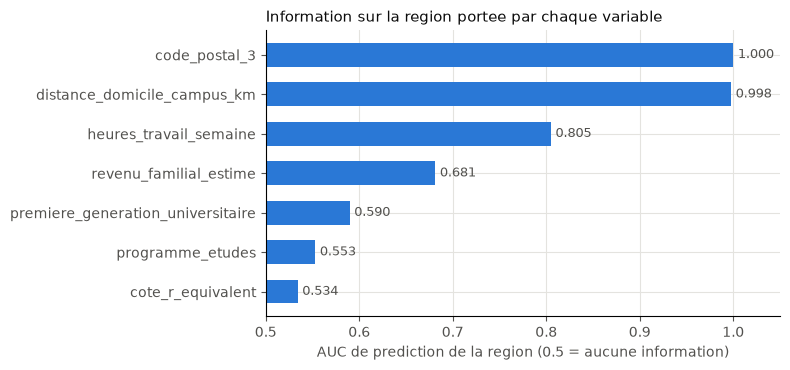

In [8]:
VARIABLES = ['cote_r_equivalent', 'revenu_familial_estime', 'heures_travail_semaine',
             'distance_domicile_campus_km', 'premiere_generation_universitaire',
             'programme_etudes', 'code_postal_3']


def auc_prediction_region(colonnes):
    """AUC en validation croisee d'un modele qui predit `eloignee` a partir de `colonnes`."""
    categorielles = [c for c in colonnes if c in ('programme_etudes', 'code_postal_3')]
    pretraitement = ColumnTransformer(
        [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorielles)],
        remainder='passthrough')
    modele = make_pipeline(pretraitement, HistGradientBoostingClassifier(max_iter=100, random_state=42))
    return cross_val_score(modele, demandes[colonnes], demandes['eloignee'], cv=5, scoring='roc_auc').mean()


auc_region = pd.Series({v: auc_prediction_region([v]) for v in VARIABLES}).sort_values()
auc_combinaisons = pd.Series({
    'toutes sauf code postal': auc_prediction_region([v for v in VARIABLES if v != 'code_postal_3']),
    'toutes sauf code postal et distance': auc_prediction_region(
        [v for v in VARIABLES if v not in ('code_postal_3', 'distance_domicile_campus_km')]),
})
print(auc_combinaisons.round(3))

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(auc_region.index, auc_region.values - 0.5, left=0.5, color=COULEURS_GROUPE['Centre'], height=0.6)
for i, v in enumerate(auc_region.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9, color=ENCRE_SECONDAIRE)
ax.set_xlim(0.5, 1.05)
ax.set_xlabel('AUC de prediction de la region (0.5 = aucune information)', color=ENCRE_SECONDAIRE)
styliser(ax, 'Information sur la region portee par chaque variable')
plt.tight_layout()
plt.show()

**Lecture.**
- `code_postal_3` (AUC 1.000) et la distance (0.998) **determinent** la région.
- Les heures travaillees (0.81) et le revenu (0.68) en portent une part importante.
- La première génération, le programme et la cote R n'en portent presque pas (0.53 a 0.59).
- Même sans code postal ni distance, les autres variables prédisent encore la région avec une AUC
  de 0.84.

### 4.2 Équité par ignorance : retirer les proxys suffit-il ?

On etend la section 5 de la baseline. Le RF est reentraine en retirant cumulativement la région, le
code postal, la distance, les heures et le revenu.

In [9]:
ETAPES = ['region_administrative', 'code_postal_3', 'distance_domicile_campus_km',
          'heures_travail_semaine', 'revenu_familial_estime']

COURTS = {'region_administrative': 'region', 'code_postal_3': 'code postal',
          'distance_domicile_campus_km': 'distance', 'heures_travail_semaine': 'heures',
          'revenu_familial_estime': 'revenu'}

lignes = {}
for k in range(len(ETAPES) + 1):
    exclues = ETAPES[:k]
    _, _, d = entrainer_rf(exclues)
    contre_ref, contre_comite = metriques_equite(y_ref, d, groupe_te), metriques_equite(y_comite, d, groupe_te)
    etiquette = 'toutes les colonnes' if not exclues else '- ' + ', '.join(COURTS[c] for c in exclues)
    lignes[etiquette] = {
        'ecart_parite': contre_ref['ecart_parite'],
        'ecart_egalite_chances (reference)': contre_ref['ecart_egalite_chances'],
        'exactitude (reference)': contre_ref['exactitude'],
        'ecart_egalite_chances (comite)': contre_comite['ecart_egalite_chances'],
        'exactitude (comite)': contre_comite['exactitude'],
    }
ignorance = pd.DataFrame(lignes).T
print(ignorance.round(3))

                                                 ecart_parite  ecart_egalite_chances (reference)  exactitude (reference)  ecart_egalite_chances (comite)  exactitude (comite)
toutes les colonnes                                     0.188                              0.315                   0.909                           0.063                0.881
- region                                                0.180                              0.300                   0.913                           0.042                0.884
- region, code postal                                   0.173                              0.259                   0.911                           0.024                0.879
- region, code postal, distance                         0.110                              0.154                   0.921                          -0.048                0.871
- region, code postal, distance, heures                 0.122                              0.173                   0.913          

**Lecture.**
- Retirer la région puis le code postal ne change presque rien : l'écart de parité passe de 0.188 a
  0.180 puis 0.173 (les chiffres de la baseline), et l'écart d'égalité des chances de 0.315 a 0.259.
- Retirer la **distance** le ramene a 0.154 : c'est le proxy le plus actif.
- Retirer ensuite les heures le fait remonter (0.173) : elles portent un critere reel, que l'étalon
  retient aussi.
- Retirer aussi le revenu le ramene a 0.117, mais l'écart reste important. Le modèle apprend toujours a
  reproduire un comité biaisée.
- Retirer des colonnes ne corrigées pas une **étiquette** biaiséee. Il faut corriger la cible
  (`model_corrige.ipynb`), pas seulement les variables.

### 4.3 Proxys purs ou criteres legitimes ?

Une variable peut porter la région **et** un effet propre sur le merite. Pour les distinguer, on ajuste
le modèle de décision **dans chaque groupe** : un effet qui persiste a l'interieur d'un groupe n'est pas
un simple reflet de la région.

                                        Centre  Eloignee  AUC prediction region
num__cote_r_equivalent                   4.043     4.064                  0.534
num__distance_domicile_campus_km         0.070     0.102                  0.998
num__heures_travail_semaine              0.624     0.663                  0.805
num__premiere_generation_universitaire   0.002    -0.056                  0.590
num__revenu_familial_estime              0.708     0.734                  0.681

Importance par permutation du RF de production (baisse d'AUC contre decision_octroi)
                                   moyenne  ecart_type
cote_r_equivalent                   0.3776      0.0080
revenu_familial_estime              0.0119      0.0009
heures_travail_semaine              0.0082      0.0007
distance_domicile_campus_km         0.0037      0.0007
region_administrative               0.0036      0.0007
premiere_generation_universitaire   0.0000      0.0001
programme_etudes                   -0.0003      0

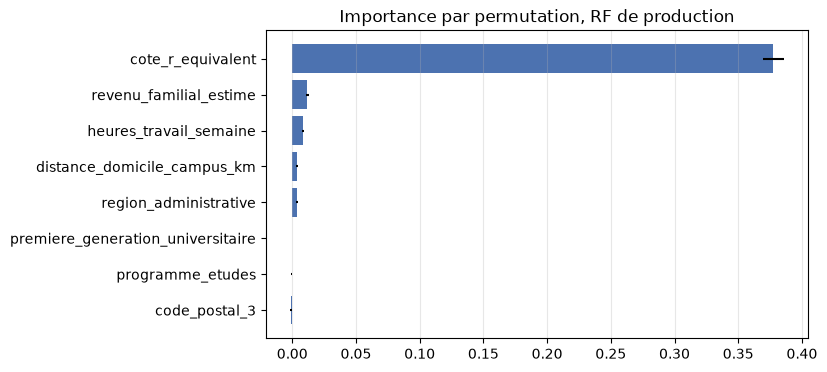

In [10]:
effets_intra_groupe = pd.DataFrame({
    g: coefficients(ajuster_modele_decision(demandes[groupe == g])) for g in ['Centre', 'Eloignee']
}).drop(index='num__eloignee').filter(like='num__', axis=0)
effets_intra_groupe['AUC prediction region'] = auc_region.reindex(
    [n.split('__')[1] for n in effets_intra_groupe.index]).to_numpy()
print(effets_intra_groupe.round(3))

print()
print('Importance par permutation du RF de production (baisse d\'AUC contre decision_octroi)')
importances = importance_permutation(rf, X_te_rf, y_comite)
print(importances.round(4))
tracer_importances(importances, 'Importance par permutation, RF de production')
plt.show()

TODO: review cell below

**Lecture.**

| Variable | Porte la région | Effet propre dans chaque groupe | Etalon (sondes HxBuddy) | Statut |
|---|---|---|---|---|
| `code_postal_3` | totalement (AUC 1.000) | aucun (non utilisé par le modèle de décision) | | **proxy pur**, exclu |
| `distance_domicile_campus_km` | presque totalement (0.998) | très faible (0.07 et 0.10) | la neutraliser : +0.15 point | **proxy pur**, exclu |
| `heures_travail_semaine` | fortement (0.81) | net (0.62 et 0.66) | la neutraliser : -1.5 point | **critere legitime**, conserve |
| `revenu_familial_estime` | moyennement (0.68) | net (0.71 et 0.73) | le neutraliser : +2.05 points | **biais du comité**, exclu |
| `premiere_generation_universitaire` | faiblement (0.59) | negligeable (0.00 et -0.06) | | neutre |

- Le comité valorise les heures travaillees et un **revenu eleve**, dans les deux groupes. Les sondes
  HxBuddy tranchent : l'étalon retient les heures (les neutraliser fait perdre 1.5 point d'exactitude),
  mais pas le revenu (le neutraliser fait gagner 2.05 points ; favoriser les bas revenus n'aide pas non
  plus). La préférence du comité pour les ménages aisés est un second biais, qui pénalisait aussi
  indirectement les régions éloignées (revenu moyen de 56 k$ contre 76 k$).
- **Paradoxe de Simpson** (`analyse_donnees.ipynb` §5) : sur l'ensemble des données, les heures ne sont
  pas corrélées a la decision (-0.02), alors qu'elles l'augmentent dans chaque groupe. Un audit par
  corrélations globales ne le verrait pas.
- Dans le RF, région, distance, heures et revenu ont chacun une importance faible par rapport a la
  cote R. Le biais est **diffus** : aucune variable unique ne le porte, d'ou l'echec de l'équité par
  ignorance.

## 5. Avant / après correction

Écart d'égalité des chances contre les trois references de mérite. Le mérite retenu est circulaire pour
le modèle corrigé, qui en est derive : les deux références indépendantes servent de contrôle.

In [11]:
def ecarts_toutes_references(y_merite, y_region, y_cote_r, decisions, groupes):
    """Ecart d'egalite des chances contre chaque reference de merite."""
    return {nom: metriques_equite(y, decisions, groupes)['ecart_egalite_chances']
            for nom, y in zip(references, [y_merite, y_region, y_cote_r])}


avant_apres = pd.concat({
    nom: intervalle_bootstrap(
        lambda a, b, c, d, g: ecarts_toutes_references(a, b, c, d, g),
        *references.values(), decisions, groupe_te, strates=groupe_te)
    for nom, decisions in [('RF de production', decisions_rf), ('modele corrige', decisions_corrige)]
}, axis=1)
avant_apres[('', 'part de l\'ecart comblee')] = (
    1 - avant_apres[('modele corrige', 'estimation')].abs() / avant_apres[('RF de production', 'estimation')].abs())
print(avant_apres.round(3))
print()
print(pd.DataFrame({
    'RF de production': metriques_equite(y_ref, decisions_rf, groupe_te),
    'modele corrige': metriques_equite(y_ref, decisions_corrige, groupe_te),
}).round(3))

                           RF de production               modele corrige                                      
                                 estimation    bas   haut     estimation    bas   haut part de l'ecart comblee
merite retenu                         0.315  0.273  0.357          0.002  0.000  0.006                   0.994
contrefactuel region seule            0.264  0.220  0.308         -0.055 -0.082 -0.029                   0.792
cote R seule                          0.238  0.196  0.280         -0.066 -0.093 -0.041                   0.723

                         RF de production  modele corrige
taux_selection_Centre               0.459           0.401
taux_selection_Eloignee             0.271           0.399
ecart_parite                        0.188           0.001
ecart_egalite_chances               0.315           0.002
ecart_fpr                           0.102           0.001
ecart_precision                    -0.134          -0.001
exactitude                          0.

In [12]:
# Soumission : predictions.csv (ecrit par model_corrige.ipynb §3.3).
soumission = pd.read_csv('predictions.csv')
assert (soumission['id_candidat'] == candidats['id_candidat']).all(), 'identifiants differents'
assert set(soumission['decision_octroi']) <= {0, 1}
taux = soumission['decision_octroi'].mean()
print(f'{len(soumission)} lignes, taux d\'octroi {taux:.1%}', '- budget respecte' if 0.36 <= taux <= 0.44 else '- HORS BUDGET')
print(soumission.groupby(groupe_cand)['decision_octroi'].mean().round(3).to_dict())

4000 lignes, taux d'octroi 40.0% - budget respecte
{'Centre': 0.399, 'Eloignee': 0.402}


**Lecture.**
- Contre le merite retenu, l'écart passe de 0.32 a 0.002 (circulaire, donc optimiste).
- Contre les deux références indépendantes, l'écart passe de 0.26 à -0.06 (contrefactuel de région
  seule) et de 0.24 a -0.07 (cote R seule) : 72 a 79 % de l'écart comble en valeur absolue, avec une
  legere inversion en faveur des régions éloignées. C'est l'estimation prudente de l'effet de la
  correction ; l'inversion vient des heures travaillees, plus elevees en région, que l'étalon valorise.
- L'écart de parité passe de 19 points à 0.1 point : avec le merite retenu, les deux groupes ont le meme
  taux de mérite (section 3).
- `predictions.csv` respecte le format et le budget (40 %), avec 39.9 % d'octroi au Centre contre
  40.2 % en région. Il concorde a 99.9 % avec la sonde de la cible retenue (94.58 % sur HxBuddy).

## 6. Limites

- **Calibration sur l'étalon** : la cible retenue a ete choisie parmi une douzaine de sondes HxBuddy. Le
  risque de surajustement est faible, car chaque parametre retenu a aussi une justification de principe
  (revenu : pas un critere de mérite ; distance : proxy pur), mais l'exactitude HxBuddy ne mesure que
  l'utilite, pas l'équité.
- **Niveau de retrait** : la pénalité régionale est retirée entièrement. Les sondes placent l'optimum
  d'exactitude vers 0.86, et les références indépendantes l'optimum d'équité vers 0.75
  (`model_corrige.ipynb` §2.2). Le choix de 1 laisse un écart légèrement favorable aux régions éloignées.
- **Pas de support commun sur la distance** : 79 % des dossiers eloignes sont hors de l'etendue de
  distance du Centre (`analyse_donnees.ipynb` §2). La distance étant neutralisée, cette extrapolation ne
  touche plus la cible ; elle reste une limite du modèle de décision.
- **Circularité partielle** : le modèle corrigé et la référence retenue dérivent du même modèle de
  decision. Les références indépendantes en limitent la portée, sans l'eliminer.
- **Données synthétiques**, un seul découpage train/test : les IC bootstrap couvrent l'incertitude
  d'echantillonnage du test, pas celle de l'entrainement.

## 7. Résumé chiffré

In [13]:
resume = pd.DataFrame({
    'estimation': [decomposition.loc['ecart_total', 'estimation'],
                   decomposition.loc['ecart_merite_retenu', 'estimation'],
                   decomposition.loc['part_inexpliquee', 'estimation'],
                   audit_rf.loc['ecart_egalite_chances', ('contre decision_octroi', 'estimation')],
                   audit_rf.loc['ecart_egalite_chances', ('contre la reference de merite', 'estimation')],
                   avant_apres.loc['contrefactuel region seule', ('modele corrige', 'estimation')],
                   avant_apres.loc['cote R seule', ('modele corrige', 'estimation')]],
    'IC 95 %': [f"[{d.loc[k, 'bas']:.3f} ; {d.loc[k, 'haut']:.3f}]" for d, k in [
        (decomposition, 'ecart_total'), (decomposition, 'ecart_merite_retenu'),
        (decomposition, 'part_inexpliquee'),
        (audit_rf['contre decision_octroi'], 'ecart_egalite_chances'),
        (audit_rf['contre la reference de merite'], 'ecart_egalite_chances'),
        (avant_apres['modele corrige'], 'contrefactuel region seule'),
        (avant_apres['modele corrige'], 'cote R seule')]],
}, index=['Comite : ecart d\'octroi Centre - Eloignee',
          'Comite : part justifiee par le merite retenu',
          'Comite : penalite regionale directe, a profil egal',
          'RF : ecart d\'egalite des chances contre decision_octroi',
          'RF : ecart d\'egalite des chances contre le merite retenu (test)',
          'Corrige : ecart contre le contrefactuel region seule',
          'Corrige : ecart contre la cote R seule'])
print(resume.round(3).to_string())

                                                                 estimation            IC 95 %
Comite : ecart d'octroi Centre - Eloignee                             0.211    [0.193 ; 0.230]
Comite : part justifiee par le merite retenu                          0.008   [-0.008 ; 0.028]
Comite : penalite regionale directe, a profil egal                    0.180    [0.153 ; 0.205]
RF : ecart d'egalite des chances contre decision_octroi               0.063    [0.014 ; 0.111]
RF : ecart d'egalite des chances contre le merite retenu (test)       0.315    [0.273 ; 0.357]
Corrige : ecart contre le contrefactuel region seule                 -0.055  [-0.082 ; -0.029]
Corrige : ecart contre la cote R seule                               -0.066  [-0.093 ; -0.041]
